In [1]:
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("results/boot_results_vqa.csv")
df = df.drop(columns=["path", "have_eval_result", "have_prediction", "have_gpt_score", "if_finished", "error"])

df

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high
0,Qwen2-VL,vqa,SLAKE,general,ZS,Qwen,0.779962,0.737981,0.819712
1,Qwen25-VL,vqa,SLAKE,general,ZS,Qwen,0.755822,0.713942,0.798077
2,Gemma3,vqa,SLAKE,general,ZS,Gemma,0.721779,0.680288,0.764423
3,MedGemma,vqa,SLAKE,medical,ZS,Gemma,0.770599,0.730769,0.810096
4,InternVL3,vqa,SLAKE,general,ZS,Intern,0.744175,0.701863,0.786058
...,...,...,...,...,...,...,...,...,...
215,gemini-2.5-pro,vqa,OmniMedVQA,medical,ucagent,Gemini,NaN,NaN,NaN
216,o3,vqa,OmniMedVQA,medical,mdagent,o-family,NaN,NaN,NaN
217,o3,vqa,OmniMedVQA,medical,ucagent,o-family,NaN,NaN,NaN
218,Lingshu,vqa,OmniMedVQA,medical,mdagent,Qwen,0.818682,0.809081,0.828160


In [3]:
ID_dict = {
    "LLaVA-Med": ["VQA-RAD", "PathVQA", "SLAKE"],
    "MedGemma": ["VQA-RAD", "PathVQA", "SLAKE"],
    "Lingshu": ["VQA-RAD", "PathVQA", "SLAKE"],
    # "gemini-2.5-pro": ["VQA-RAD", "PathVQA", "SLAKE", "Harvard-FairVLMed10k"],
    # "o3": ["VQA-RAD", "PathVQA", "SLAKE", "Harvard-FairVLMed10k"],
}

is_ood = []

for dataset, model in zip(df["dataset"].tolist(), df["model"].tolist()):
    if not model in ID_dict.keys():
        is_ood.append(1)
    elif dataset not in ID_dict[model]:
        is_ood.append(1)
    else:
        is_ood.append(0)

df["is_ood"] = is_ood

In [4]:
df["model_family"].unique()

array(['Qwen', 'Gemma', 'Intern', 'LLaVA', 'Gemini', 'o-family'],
      dtype=object)

# heatmap

In [5]:
df["dataset+tune_module"] = df["dataset"] + "-" + df["trainable_module"]

model_order = [
    # "o3",
    # "gemini-2.5-pro",
    "LLaVA-1.5",
    "LLaVA-Med",
    "Qwen2-VL",
    "Qwen25-VL",
    "Lingshu",
    "Gemma3",
    "MedGemma",
    # "VILA",
    # "VILA-M3",
    "InternVL3",
]

data_order = [
    "VQA-RAD-ZS",
    "VQA-RAD-mdagent",
    "VQA-RAD-ucagent",
    "PathVQA-ZS",
    "PathVQA-mdagent",
    "PathVQA-ucagent",
    "SLAKE-ZS",
    "SLAKE-mdagent",
    "SLAKE-ucagent",
    "Harvard-FairVLMed10k-ZS",
    "Harvard-FairVLMed10k-mdagent",
    "Harvard-FairVLMed10k-ucagent",
    "MedXpertQA-ZS",
    "MedXpertQA-mdagent",
    "MedXpertQA-ucagent",
    "OmniMedVQA-ZS",
    "OmniMedVQA-mdagent",
    "OmniMedVQA-ucagent",
]

metric = "acc"
df_plot = df.copy(deep=True)
df_plot = df_plot.loc[~df_plot["model"].isin(["VILA", "VILA-M3"])]

df_plot[metric] = df_plot[metric] * 100

data_heatmap = df_plot.pivot(
    index="model", columns="dataset+tune_module", values=metric)
data_heatmap = data_heatmap.reindex(model_order, axis=0)
data_heatmap = data_heatmap.reindex(data_order, axis=1)
data_heatmap

dataset+tune_module,VQA-RAD-ZS,VQA-RAD-mdagent,VQA-RAD-ucagent,PathVQA-ZS,PathVQA-mdagent,PathVQA-ucagent,SLAKE-ZS,SLAKE-mdagent,SLAKE-ucagent,Harvard-FairVLMed10k-ZS,Harvard-FairVLMed10k-mdagent,Harvard-FairVLMed10k-ucagent,MedXpertQA-ZS,MedXpertQA-mdagent,MedXpertQA-ucagent,OmniMedVQA-ZS,OmniMedVQA-mdagent,OmniMedVQA-ucagent
model,,,,,,,,,,,,,,,,,,
LLaVA-1.5,52.445020,48.914343,39.870916,54.725193,47.537151,38.297353,63.995433,64.794712,48.319952,45.434419,50.250651,39.408968,NaN,NaN,NaN,52.111575,47.099159,38.369059
LLaVA-Med,69.790837,59.755777,68.227490,66.000803,66.183254,65.997829,62.342308,54.685817,59.450962,76.128808,72.187074,75.826152,NaN,NaN,NaN,40.885435,33.020724,36.139169
Qwen2-VL,75.225498,72.445020,70.505578,68.274390,67.758626,70.521267,77.996154,72.368269,69.520192,58.582064,61.515130,67.152204,21.7980,22.78925,25.80325,69.131975,65.334885,65.586793
Qwen25-VL,70.827092,67.350996,72.542231,62.358477,61.477097,72.672249,75.582212,72.756490,76.458894,61.417134,57.897846,65.377505,24.0095,18.47025,21.97050,64.019253,61.388425,61.561558
Lingshu,70.474900,68.510757,65.634661,81.527365,80.287091,68.763891,77.694471,77.005529,77.676683,66.157164,64.331112,52.662776,24.7795,23.96175,31.25925,83.417087,81.868186,74.129842
Gemma3,58.247012,61.710757,64.083267,76.212344,62.107644,67.758388,72.177885,67.525000,72.609135,66.645892,55.772244,52.300100,21.7820,15.74950,17.99750,58.789735,59.866052,59.548238
MedGemma,76.424701,76.424701,80.158167,70.665229,66.284830,70.304402,77.059856,85.161298,83.372356,61.613176,58.117285,65.470591,25.9250,22.97375,26.96850,69.430310,71.621532,69.976657
InternVL3,70.202390,75.315936,74.033466,70.862909,67.596550,73.624390,74.417548,80.103125,79.337500,60.735371,62.028758,62.641433,23.5140,22.72125,27.46675,75.673295,79.736195,75.790268


In [6]:
mask = df_plot.pivot(index="model", columns="dataset+tune_module", values="is_ood")
mask = mask.reindex(model_order, axis=0)
mask = mask.reindex(data_order, axis=1)
mask

dataset+tune_module,VQA-RAD-ZS,VQA-RAD-mdagent,VQA-RAD-ucagent,PathVQA-ZS,PathVQA-mdagent,PathVQA-ucagent,SLAKE-ZS,SLAKE-mdagent,SLAKE-ucagent,Harvard-FairVLMed10k-ZS,Harvard-FairVLMed10k-mdagent,Harvard-FairVLMed10k-ucagent,MedXpertQA-ZS,MedXpertQA-mdagent,MedXpertQA-ucagent,OmniMedVQA-ZS,OmniMedVQA-mdagent,OmniMedVQA-ucagent
model,,,,,,,,,,,,,,,,,,
LLaVA-1.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0
LLaVA-Med,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0
Qwen2-VL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Qwen25-VL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Lingshu,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gemma3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
MedGemma,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
InternVL3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [7]:
mask.shape

(8, 18)

# heatmap

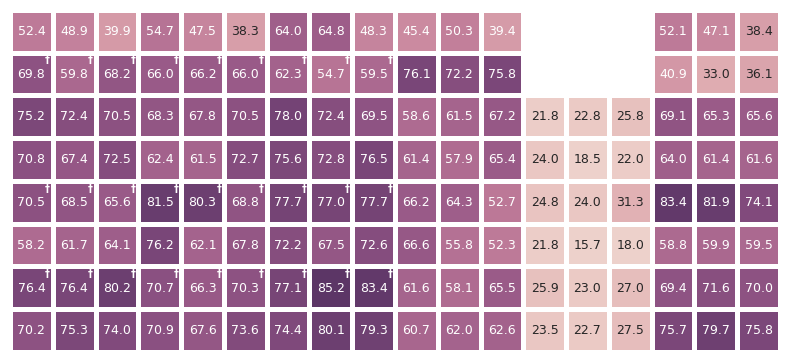

In [8]:
def prepare_annot_for_heatmap(data):
    annot = np.array(data).copy()
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            annot[i, j] = "{:.1f}".format(float(annot[i, j]))
    return annot


scale = 1
fig, ax = plt.subplots(figsize=(mask.shape[0] * scale, mask.shape[1] * scale))

heat = sns.heatmap(
    data_heatmap,
    cbar=False,
    cmap=sns.cubehelix_palette(as_cmap=True),
    annot=prepare_annot_for_heatmap(data_heatmap),
    ax=ax,
    yticklabels=False,
    xticklabels=False,
    fmt="",
    square=True,
    linewidths=2.5 * scale,
    annot_kws={"size": 9},
    vmin=20,
    vmax=100,
)

mask = np.array(mask).astype(bool)


# Add asterisks to the specified cells
for i in range(data_heatmap.shape[0]):
    for j in range(data_heatmap.shape[1]):
        if not mask[i, j]:  # Check if the cell is marked for asterisk
            ax.text(
                j + 0.88,  # Adjust position slightly to the right of the cell
                i + 0.18,  # Center vertically
                "†",
                color="white",  # Asterisk color (contrast with heatmap)
                fontsize=7,
                ha="center",
                va="center",
                weight="bold",
            )

ax.tick_params(right=False, left=True, labelleft=False)
# ax.set_yticks(np.arange(8) + 0.5)
# ax.set_xticks(np.arange(12) + 0.5)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    "figures/vqa_agent_heatmap",
    dpi=400,
    bbox_inches="tight",
)

# family-wise comparison

In [9]:
datasets = ["VQA-RAD", "PathVQA", "SLAKE",
            "Harvard-FairVLMed10k", "MedXpertQA", "OmniMedVQA"]
model_families = {
    "LLaVA": [
        "LLaVA-Med",
        "LLaVA-1.5",
    ],
    "Qwen": [
        "Lingshu",
        "Qwen2-VL",
        "Qwen25-VL",
    ],
    "Gemma": [
        "MedGemma",
        "Gemma3",
    ],
}

palette = sns.color_palette("Set2", len(datasets))
color_dict = dict(zip(datasets, palette))

color_dict

{'VQA-RAD': (0.4, 0.7607843137254902, 0.6470588235294118),
 'PathVQA': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 'SLAKE': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 'Harvard-FairVLMed10k': (0.9058823529411765,
  0.5411764705882353,
  0.7647058823529411),
 'MedXpertQA': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 'OmniMedVQA': (1.0, 0.8509803921568627, 0.1843137254901961)}

In [10]:
def get_general_medical_df_sub(df, rq, family):
    df_sub = df.loc[(df["trainable_module"].isin(["ZS", "mdagent", "ucagent"])) & (df["model_family"] == family)]
    if rq == 1:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["trainable_module"] == "ZS")]
        df_sub_medical = df_sub.loc[(df_sub["model_type"] == "medical") & (df_sub["trainable_module"] == "ZS")]
    elif rq == 2:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["trainable_module"] == "mdagent")]
        df_sub_medical = df_sub.loc[(df_sub["model_type"] == "medical") & (df_sub["trainable_module"] == "mdagent")]

    elif rq == 3:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["trainable_module"] == "ucagent")]
        df_sub_medical = df_sub.loc[(df_sub["model_type"] == "medical") & (df_sub["trainable_module"] == "ucagent")]

    df_sub = pd.concat([df_sub_general, df_sub_medical]).reset_index(drop=True)
    df_sub = df_sub.loc[df_sub["dataset"].isin(df_sub_medical["dataset"].unique())]

    return df_sub, df_sub_general, df_sub_medical

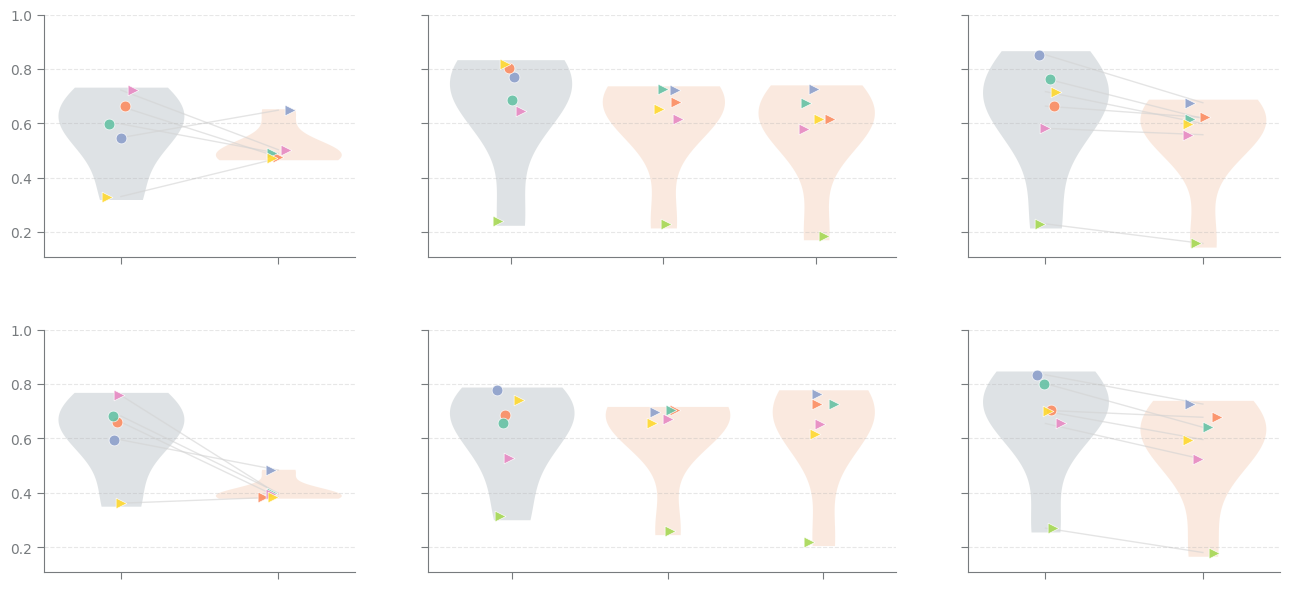

In [11]:
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon

fig, axes = plt.subplots(2, 3, figsize=(13, 6), gridspec_kw={"width_ratios": [2, 3, 2]}, sharey=True)

# 淡色 violin 颜色
violin_palette = {
    "medical": "#cfd8dc",
    "general": "#ffe0cc",
}

for rq in range(2, 4):
    for idx_family, family in enumerate(model_families.keys()):
        cur_ax = axes[rq - 2, idx_family]

        df_sub, df_sub_general, df_sub_medical = get_general_medical_df_sub(df, rq, family)

        df_sub = df_sub.dropna(subset=["model", "acc", "dataset"])

        model_order = model_families[family]
        datasets_unique = df_sub["dataset"].unique()

        # ================================
        # 1️⃣ Violin 分两次画（现在竖向）
        # ================================
        for mtype in ["medical", "general"]:
            df_tmp = df_sub[df_sub["model_type"] == mtype]

            if len(df_tmp) > 0:
                sns.violinplot(
                    data=df_tmp,
                    x="model",
                    y="acc",
                    order=model_order,
                    ax=cur_ax,
                    inner=None,
                    linewidth=0,
                    color=violin_palette[mtype],
                    cut=0.1,
                    alpha=0.7,
                )

        # ================================
        # 2️⃣ Scatter + x轴 jitter
        # ================================
        x_positions = {model: i for i, model in enumerate(model_order)}

        for d in datasets_unique:
            df_d = df_sub[df_sub["dataset"] == d]

            for _, row in df_d.iterrows():
                x_base = x_positions[row["model"]]

                # jitter 改成 x jitter
                x_jitter = x_base + np.random.uniform(-0.1, 0.1)

                is_ood = row["is_ood"]
                marker_style = "o" if is_ood == 0 else ">"

                cur_ax.scatter(
                    x_jitter,
                    row["acc"],
                    color=color_dict[d],
                    s=60,
                    alpha=0.9,
                    zorder=3,
                    marker=marker_style,
                    edgecolor="white",
                    linewidth=0.5,
                )

        # ================================
        # 3️⃣ 两模型时加 paired 线（现在竖向连线）
        # ================================
        if len(model_order) == 2:
            for d in datasets_unique:
                df_d = df_sub[df_sub["dataset"] == d].sort_values("model")
                if len(df_d) == 2:
                    x0 = x_positions[df_d.iloc[0]["model"]]
                    x1 = x_positions[df_d.iloc[1]["model"]]

                    cur_ax.plot(
                        [x0, x1],
                        df_d["acc"].values,
                        color="lightgray",
                        alpha=0.6,
                        linewidth=1,
                        zorder=1,
                    )

        # ================================
        # 美化
        # ================================
        cur_ax.set_xlabel("")
        cur_ax.set_ylabel("")

        cur_ax.grid(axis="y", linestyle="--", alpha=0.3)

        cur_ax.spines["top"].set_visible(False)
        cur_ax.spines["right"].set_visible(False)

        cur_ax.spines["bottom"].set_color("#777b7e")
        cur_ax.spines["left"].set_color("#777b7e")
        cur_ax.spines["bottom"].set_linewidth(0.8)
        cur_ax.spines["left"].set_linewidth(0.8)

        cur_ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1])
        # cur_ax.set_yticklabels([])
        cur_ax.set_xticklabels([])

        cur_ax.tick_params(
            axis="both",
            which="both",
            direction="out",
            length=5,
            width=0.8,
            colors="#777b7e",
        )

plt.tight_layout()
fig.subplots_adjust(hspace=0.3, wspace=0.2)

plt.savefig(
    "figures/vqa_agent_family_compare",
    dpi=400,
    bbox_inches="tight",
)

In [12]:
for rq in range(1, 4):
    for idx_family, family in enumerate(model_families.keys()):
        df_sub, df_sub_general, df_sub_medical = get_general_medical_df_sub(
            df, rq, family)

        # ================================
        # LMM
        # ================================

        # 只保留 medical/general
        df_lmm = df_sub.copy()

        # 确保分类变量
        df_lmm["model_type"] = df_lmm["model_type"].astype("category")

        # 设定 reference = medical（可改）
        df_lmm["model_type"] = df_lmm["model_type"].cat.reorder_categories(
            ["medical", "general"], ordered=True)

        # Mixed model
        model = smf.mixedlm("acc ~ model_type", df_lmm,
                            groups=df_lmm["dataset"])

        result = model.fit()

        beta = result.params["model_type[T.general]"]
        ci_low, ci_high = result.conf_int().loc["model_type[T.general]"]
        p_value = result.pvalues["model_type[T.general]"]

        print("\n" + "-" * 40)
        print(f"{family} - RQ{rq}")
        print(f"β = {beta:.3f}")
        print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")
        print(f"p = {p_value:.4f}")

        # ================================
        # paired p value
        # ================================

        model_order = model_families[family]
        # 1️⃣ 设置有序 categorical
        df_sub["model"] = pd.Categorical(
            df_sub["model"], categories=model_order, ordered=True)

        # 2️⃣ 排序 dataframe
        df_sub = df_sub.sort_values("model")

        medical_models = df_sub[df_sub["model_type"]
                                == "medical"]["model"].unique()
        general_models = df_sub[df_sub["model_type"]
                                == "general"]["model"].unique()

        # 初始化矩阵
        p_matrix = pd.DataFrame(
            np.nan, index=medical_models, columns=general_models)

        annot_matrix = pd.DataFrame(
            "", index=medical_models, columns=general_models)

        for m_med in medical_models:
            for m_gen in general_models:

                df_med = df_sub[df_sub["model"] == m_med][["dataset", "acc"]]
                df_gen = df_sub[df_sub["model"] == m_gen][["dataset", "acc"]]

                df_pair = df_med.merge(
                    df_gen, on="dataset", suffixes=("_med", "_gen"))

                n_pair = len(df_pair)

                if n_pair >= 2:
                    stat, p = wilcoxon(df_pair["acc_med"], df_pair["acc_gen"])

                    p_matrix.loc[m_med, m_gen] = p
                    annot_matrix.loc[m_med, m_gen] = f"p={p:.3f} n={n_pair}"
                else:
                    annot_matrix.loc[m_med, m_gen] = f"n={n_pair}"

        print(annot_matrix)

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



----------------------------------------
LLaVA - RQ1
β = -0.093
95% CI = [-0.224, 0.038]
p = 0.1654
             LLaVA-1.5
LLaVA-Med  p=0.312 n=5

----------------------------------------
Qwen - RQ1
β = -0.066
95% CI = [-0.115, -0.017]
p = 0.0084
            Qwen2-VL    Qwen25-VL
Lingshu  p=0.219 n=6  p=0.062 n=6

----------------------------------------
Gemma - RQ1
β = -0.045
95% CI = [-0.119, 0.028]
p = 0.2229
               Gemma3
MedGemma  p=0.562 n=6

----------------------------------------
LLaVA - RQ2
β = -0.054
95% CI = [-0.200, 0.091]
p = 0.4623
             LLaVA-1.5
LLaVA-Med  p=0.438 n=5

----------------------------------------
Qwen - RQ2
β = -0.075
95% CI = [-0.123, -0.028]
p = 0.0019
            Qwen2-VL    Qwen25-VL
Lingshu  p=0.156 n=6  p=0.031 n=6

----------------------------------------
Gemma - RQ2
β = -0.096
95% CI = [-0.145, -0.048]
p = 0.0001
               Gemma3
MedGemma  p=0.031 n=6

----------------------------------------
LLaVA - RQ3
β = -0.203
95% CI = [-0

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [13]:
for agent in ["mdagent", "ucagent"]:
    for idx_family, family in enumerate(model_families.keys()):
        df_sub = df.loc[(df["trainable_module"].isin(["ZS", agent])) & (df["model_family"] == family)]

        # ================================
        # LMM
        # ================================

        # 只保留 medical/general
        df_lmm = df_sub.copy()

        # 确保分类变量
        df_lmm["model_type"] = df_lmm["model_type"].astype("category")

        # 设定 reference = medical（可改）
        df_lmm["model_type"] = df_lmm["model_type"].cat.reorder_categories(["medical", "general"], ordered=True)

        df_lmm["trainable_module"] = df_lmm["trainable_module"].astype("category")
        df_lmm["trainable_module"] = df_lmm["trainable_module"].cat.reorder_categories(["ZS", agent], ordered=True)

        # Mixed model
        model = smf.mixedlm("acc ~ model_type * trainable_module", df_lmm, groups=df_lmm["dataset"])

        result = model.fit()

        # print("\n" + "=" * 60)
        # print(f"{family} - {agent}")
        # print(result.summary())

        # ================================
        # 提取交互项
        # ================================

        interaction_term = f"model_type[T.general]:trainable_module[T.{agent}]"

        if interaction_term in result.params.index:

            beta = result.params[interaction_term]
            ci_low, ci_high = result.conf_int().loc[interaction_term]
            p_value = result.pvalues[interaction_term]

            print("\n" + "=" * 60)
            print("\n--- Interaction Effect ---")
            print(f"{family} - {agent}")
            print(f"β = {beta:.4f}")
            print(f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")
            print(f"p = {p_value:.6f}")

        else:
            print("⚠️ Interaction term not found (check category names)")

        # beta = result.params["model_type[T.general]"]
        # ci_low, ci_high = result.conf_int().loc["model_type[T.general]"]
        # p_value = result.pvalues["model_type[T.general]"]

        # print("\n" + "-" * 40)
        # print(f"{family} -- {agent}")
        # print(f"β = {beta:.3f}")
        # print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")
        # print(f"p = {p_value:.4f}")

        # # ================================
        # # paired p value
        # # ================================

        # model_order = model_families[family]
        # # 1️⃣ 设置有序 categorical
        # df_sub["model"] = pd.Categorical(df_sub["model"], categories=model_order, ordered=True)

        # # 2️⃣ 排序 dataframe
        # df_sub = df_sub.sort_values("model")

        # medical_models = df_sub[df_sub["model_type"] == "medical"]["model"].unique()
        # general_models = df_sub[df_sub["model_type"] == "general"]["model"].unique()

        # # 初始化矩阵
        # p_matrix = pd.DataFrame(np.nan, index=medical_models, columns=general_models)

        # annot_matrix = pd.DataFrame("", index=medical_models, columns=general_models)

        # for m_med in medical_models:
        #     for m_gen in general_models:

        #         df_med = df_sub[df_sub["model"] == m_med][["dataset", "acc"]]
        #         df_gen = df_sub[df_sub["model"] == m_gen][["dataset", "acc"]]

        #         df_pair = df_med.merge(df_gen, on="dataset", suffixes=("_med", "_gen"))

        #         n_pair = len(df_pair)

        #         if n_pair >= 2:
        #             stat, p = wilcoxon(df_pair["acc_med"], df_pair["acc_gen"])

        #             p_matrix.loc[m_med, m_gen] = p
        #             annot_matrix.loc[m_med, m_gen] = f"p={p:.3f} n={n_pair}"
        #         else:
        #             annot_matrix.loc[m_med, m_gen] = f"n={n_pair}"

        print(annot_matrix)



--- Interaction Effect ---
LLaVA - mdagent
β = 0.0384
95% CI = [-0.1307, 0.2075]
p = 0.656326
               Gemma3
MedGemma  p=0.031 n=6


--- Interaction Effect ---
Qwen - mdagent
β = -0.0096
95% CI = [-0.0715, 0.0523]
p = 0.761574
               Gemma3
MedGemma  p=0.031 n=6


--- Interaction Effect ---
Gemma - mdagent
β = -0.0510
95% CI = [-0.1361, 0.0341]
p = 0.240280
               Gemma3
MedGemma  p=0.031 n=6


--- Interaction Effect ---
LLaVA - ucagent
β = -0.1099
95% CI = [-0.2735, 0.0537]
p = 0.188040
               Gemma3
MedGemma  p=0.031 n=6


--- Interaction Effect ---
Qwen - ucagent
β = 0.0652
95% CI = [-0.0028, 0.1333]
p = 0.060352
               Gemma3
MedGemma  p=0.031 n=6


--- Interaction Effect ---
Gemma - ucagent
β = -0.0578
95% CI = [-0.1343, 0.0187]
p = 0.138632
               Gemma3
MedGemma  p=0.031 n=6


/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [14]:
df_sub

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high,is_ood,dataset+tune_module
2,Gemma3,vqa,SLAKE,general,ZS,Gemma,0.721779,0.680288,0.764423,1,SLAKE-ZS
3,MedGemma,vqa,SLAKE,medical,ZS,Gemma,0.770599,0.730769,0.810096,0,SLAKE-ZS
12,Gemma3,vqa,PathVQA,general,ZS,Gemma,0.762123,0.747167,0.776324,1,PathVQA-ZS
13,MedGemma,vqa,PathVQA,medical,ZS,Gemma,0.706652,0.692140,0.721892,0,PathVQA-ZS
22,Gemma3,vqa,VQA-RAD,general,ZS,Gemma,0.582470,0.521912,0.637450,1,VQA-RAD-ZS
23,MedGemma,vqa,VQA-RAD,medical,ZS,Gemma,0.764247,0.713147,0.816733,0,VQA-RAD-ZS
32,Gemma3,vqa,Harvard-FairVLMed10k,general,ZS,Gemma,0.666459,0.646794,0.686373,1,Harvard-FairVLMed10k-ZS
33,MedGemma,vqa,Harvard-FairVLMed10k,medical,ZS,Gemma,0.616132,0.593687,0.636273,1,Harvard-FairVLMed10k-ZS
42,Gemma3,vqa,MedXpertQA,general,ZS,Gemma,0.217820,0.182438,0.260000,1,MedXpertQA-ZS
43,MedGemma,vqa,MedXpertQA,medical,ZS,Gemma,0.259250,0.215000,0.302500,1,MedXpertQA-ZS


/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


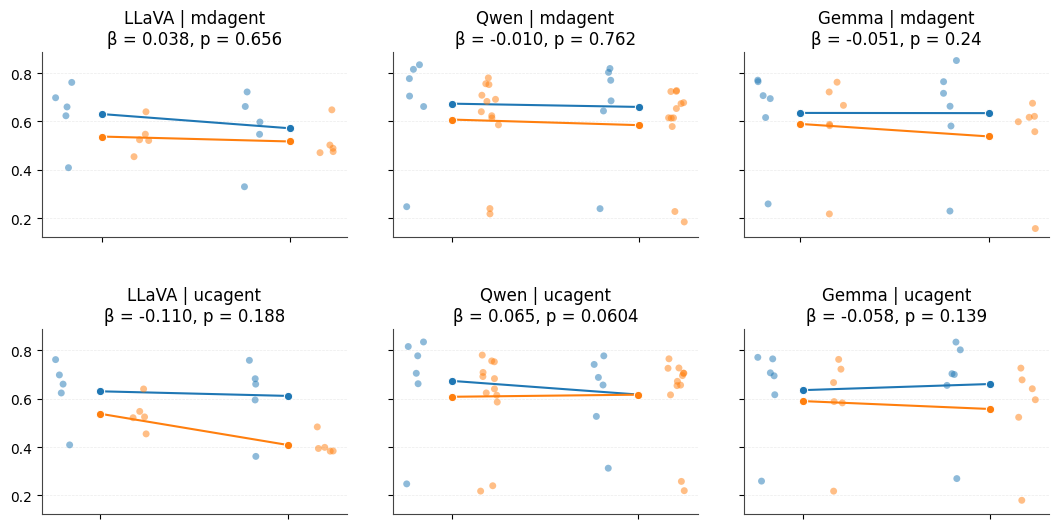

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

agents = ["mdagent", "ucagent"]
families = list(model_families.keys())

n_rows = len(agents)
n_cols = len(families)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 6), sharey=True)

# 如果只有1行或1列，确保axes可索引
if n_rows == 1:
    axes = np.expand_dims(axes, 0)
if n_cols == 1:
    axes = np.expand_dims(axes, 1)

for i, agent in enumerate(agents):
    for j, family in enumerate(families):

        ax = axes[i, j]

        df_sub = df.loc[(df["trainable_module"].isin(["ZS", agent])) & (df["model_family"] == family)]

        df_lmm = df_sub.copy()

        # categorical
        df_lmm["model_type"] = pd.Categorical(df_lmm["model_type"], categories=["medical", "general"], ordered=True)

        df_lmm["trainable_module"] = pd.Categorical(df_lmm["trainable_module"], categories=["ZS", agent], ordered=True)

        # ======================
        # Mixed Model
        # ======================
        model = smf.mixedlm("acc ~ model_type * trainable_module", df_lmm, groups=df_lmm["dataset"])

        result = model.fit()

        interaction_term = f"model_type[T.general]:trainable_module[T.{agent}]"

        if interaction_term in result.params.index:
            beta = result.params[interaction_term]
            p_value = result.pvalues[interaction_term]
        else:
            beta = np.nan
            p_value = np.nan

        # ======================
        # 1️⃣ 画原始散点
        # ======================

        sns.stripplot(
            data=df_lmm, x="trainable_module", y="acc", hue="model_type", dodge=0.2, alpha=0.5, ax=ax, legend=False
        )

        # ======================
        # 2️⃣ 计算预测值（fixed effects）
        # ======================

        pred_df = pd.DataFrame(
            {
                "model_type": ["medical", "medical", "general", "general"],
                "trainable_module": ["ZS", agent, "ZS", agent],
            }
        )

        pred_df["model_type"] = pd.Categorical(pred_df["model_type"], categories=["medical", "general"], ordered=True)

        pred_df["trainable_module"] = pd.Categorical(
            pred_df["trainable_module"], categories=["ZS", agent], ordered=True
        )

        pred_df["pred_acc"] = result.predict(pred_df)

        # ======================
        # 3️⃣ 画拟合线
        # ======================

        sns.lineplot(
            data=pred_df, x="trainable_module", y="pred_acc", hue="model_type", marker="o", legend=False, ax=ax
        )

        # ======================
        # 4️⃣ subplot 标题
        # ======================

        ax.set_title(f"{family} | {agent}\n" f"β = {beta:.3f}, p = {p_value:.3g}")

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.set_xticklabels([])

        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.25)

        # 只保留左和下边框
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_color("#444444")
        ax.spines["bottom"].set_color("#444444")

        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

        # 移除重复 legend
        # if not (i == 0 and j == 0):
        #     ax.get_legend().remove()

# 统一 legend
# handles, labels = axes[0, 0].get_legend_handles_labels()
# fig.legend(handles[:2], labels[:2], loc="upper center", ncol=2)

plt.subplots_adjust(wspace=0.15, hspace=0.5)
plt.show()

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


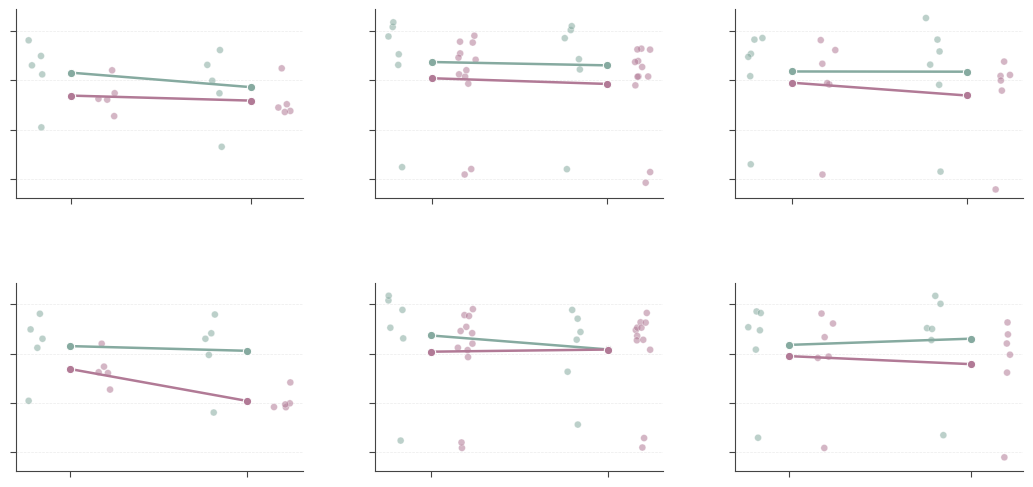

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ==========================
# 1️⃣ 全局风格设置（Nature风）
# ==========================


# 更克制配色
palette = {
    "medical": "#86aaa0",  # muted blue
    "general": "#b17a96",  # muted orange
}

agents = ["mdagent", "ucagent"]
families = list(model_families.keys())

n_rows = len(agents)
n_cols = len(families)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 6), sharey=True)

if n_rows == 1:
    axes = np.expand_dims(axes, 0)
if n_cols == 1:
    axes = np.expand_dims(axes, 1)

for i, agent in enumerate(agents):
    for j, family in enumerate(families):

        ax = axes[i, j]

        df_sub = df.loc[(df["trainable_module"].isin(["ZS", agent])) & (
            df["model_family"] == family)].copy()

        df_sub["model_type"] = pd.Categorical(
            df_sub["model_type"],
            categories=["medical", "general"],
            ordered=True,
        )

        df_sub["trainable_module"] = pd.Categorical(
            df_sub["trainable_module"],
            categories=["ZS", agent],
            ordered=True,
        )

        # ======================
        # Mixed Model
        # ======================

        df_lmm = df_sub.dropna(subset=["acc", "dataset"])

        model = smf.mixedlm(
            "acc ~ model_type * trainable_module",
            df_lmm,
            groups=df_lmm["dataset"],
        )

        result = model.fit()

        # ======================
        # 1️⃣ 原始散点（更高级）
        # ======================

        sns.stripplot(
            data=df_lmm,
            x="trainable_module",
            y="acc",
            hue="model_type",
            dodge=0.25,
            palette=palette,
            alpha=0.55,
            size=5,
            edgecolor="white",
            linewidth=0.4,
            ax=ax,
            legend=False,
            zorder=2,
        )

        # ======================
        # 2️⃣ 预测值
        # ======================

        pred_df = pd.DataFrame(
            {
                "model_type": ["medical", "medical", "general", "general"],
                "trainable_module": ["ZS", agent, "ZS", agent],
            }
        )

        pred_df["model_type"] = pd.Categorical(
            pred_df["model_type"],
            categories=["medical", "general"],
            ordered=True,
        )

        pred_df["trainable_module"] = pd.Categorical(
            pred_df["trainable_module"],
            categories=["ZS", agent],
            ordered=True,
        )

        pred_df["pred_acc"] = result.predict(pred_df)

        # ======================
        # 3️⃣ 拟合线（更细更克制）
        # ======================

        sns.lineplot(
            data=pred_df,
            x="trainable_module",
            y="pred_acc",
            hue="model_type",
            palette=palette,
            marker="o",
            markersize=6,
            linewidth=1.8,
            legend=False,
            ax=ax,
            zorder=3,
        )

        # ======================
        # 4️⃣ 高级排版
        # ======================

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        # 只保留左和下边框
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_color("#444444")
        ax.spines["bottom"].set_color("#444444")

        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

        # 轻微 y 网格
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.25)

        ax.tick_params(
            axis="both",
            direction="out",
            length=4,
            width=0.8,
            colors="#444444",
        )


plt.subplots_adjust(
    wspace=0.25,
    hspace=0.45,
)

plt.savefig(
    "figures/vqa_agent_benefits_nature_style.png",
    dpi=1200,
    bbox_inches="tight",
)

In [17]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests


# =============================================================
# 工具函数：构造跨 family 合并的 df（RQ4 用）
# =============================================================
def build_rq4_df(df, families, modules):
    """把指定 families 和 trainable_module 的数据合并起来"""
    df_list = []
    for family in families:
        sub = df.loc[(df["trainable_module"].isin(modules)) & (df["model_family"] == family)].copy()
        sub["family"] = family
        df_list.append(sub)
    out = pd.concat(df_list, ignore_index=True)

    out["model_type"] = pd.Categorical(out["model_type"], categories=["medical", "general"], ordered=True)
    out["dataset"] = out["dataset"].astype("category")
    out["family"] = out["family"].astype("category")
    out["model"] = out["model"].astype("category")
    return out


def fit_nested_lmm(df_rq, formula):
    """
    嵌套随机效应:
      - dataset
      - family
      - model nested in family
    失败时 fallback 到 dataset + model（去掉 family）
    """
    try:
        m = smf.mixedlm(
            formula,
            df_rq,
            groups=np.ones(len(df_rq)),
            re_formula="0",
            vc_formula={
                "dataset": "0 + C(dataset)",
                "family": "0 + C(family)",
                "model_in_fam": "0 + C(family):C(model)",
            },
        )
        res = m.fit(reml=True, method="lbfgs")
        return res, False
    except Exception as e:
        print(f"[warn] nested RE failed: {e}  → fallback")
        m = smf.mixedlm(
            formula,
            df_rq,
            groups=np.ones(len(df_rq)),
            re_formula="0",
            vc_formula={
                "dataset": "0 + C(dataset)",
                "model": "0 + C(model)",
            },
        )
        res = m.fit(reml=True, method="lbfgs")
        return res, True


# =============================================================
# 方案 A（主分析）：三水平统一 LMM
#   trainable_module ∈ {ZS, mdagent, ucagent}
#   一次得到两个 interaction: general:mdagent, general:ucagent
# =============================================================
print("\n" + "#" * 70)
print("# 方案 A — Unified LMM (ZS as shared baseline)")
print("#" * 70)

df_unified = build_rq4_df(df, list(model_families.keys()), ["ZS", "mdagent", "ucagent"])
df_unified["trainable_module"] = pd.Categorical(
    df_unified["trainable_module"],
    categories=["ZS", "mdagent", "ucagent"],
    ordered=True,
)

res_A, fb_A = fit_nested_lmm(
    df_unified,
    formula="acc ~ model_type * trainable_module",
)

results_A = []
for agent in ["mdagent", "ucagent"]:
    term = f"model_type[T.general]:trainable_module[T.{agent}]"
    if term in res_A.params.index:
        beta = res_A.params[term]
        ci_low, ci_high = res_A.conf_int().loc[term]
        p = res_A.pvalues[term]
        results_A.append(
            {
                "agent": agent,
                "beta": beta,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p": p,
            }
        )
        print(f"\n--- interaction: general × {agent} ---")
        print(f"β = {beta:.4f}   95% CI = [{ci_low:.4f}, {ci_high:.4f}]   p = {p:.4g}")

# FDR on the 2 interaction terms
df_A = pd.DataFrame(results_A)
_, q, _, _ = multipletests(df_A["p"].values, alpha=0.1, method="fdr_bh")
df_A["q_fdr_bh"] = q
df_A["sig_fdr"] = df_A["q_fdr_bh"] < 0.1
print("\n>>> Unified LMM summary (with BH-FDR):")
print(df_A)


# =============================================================
# 方案 B（敏感性分析）：每个 agent 单独一个 LMM
# =============================================================
print("\n\n" + "#" * 70)
print("# 方案 B — Separate LMM per agent (sensitivity)")
print("#" * 70)

results_B = []

for agent in ["mdagent", "ucagent"]:
    df_rq = build_rq4_df(df, list(model_families.keys()), ["ZS", agent])
    df_rq["trainable_module"] = pd.Categorical(df_rq["trainable_module"], categories=["ZS", agent], ordered=True)

    res, fb = fit_nested_lmm(df_rq, formula="acc ~ model_type * trainable_module")

    term = f"model_type[T.general]:trainable_module[T.{agent}]"
    if term not in res.params.index:
        print(f"⚠️ interaction term not found for {agent}")
        continue

    beta = res.params[term]
    ci_low, ci_high = res.conf_int().loc[term]
    p = res.pvalues[term]

    # 也把 main effects 打印出来，便于解释
    main_mt = res.params.get("model_type[T.general]", np.nan)
    main_tm = res.params.get(f"trainable_module[T.{agent}]", np.nan)

    print("\n" + "=" * 60)
    print(f"Agent = {agent}  (pooled across families)")
    print("=" * 60)
    print(f"main model_type[general]        β = {main_mt:.4f}")
    print(f"main trainable_module[{agent}]  β = {main_tm:.4f}")
    print(f"INTERACTION general × {agent}:")
    print(f"  β = {beta:.4f}   95% CI = [{ci_low:.4f}, {ci_high:.4f}]   p = {p:.4g}")
    print(
        f"n_obs={len(df_rq)}  datasets={df_rq['dataset'].nunique()}  "
        f"families={df_rq['family'].nunique()}  models={df_rq['model'].nunique()}" + ("  [fallback RE]" if fb else "")
    )

    results_B.append(
        {
            "agent": agent,
            "beta": beta,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p": p,
            "n_obs": len(df_rq),
            "fallback": fb,
        }
    )

df_B = pd.DataFrame(results_B)
_, q, _, _ = multipletests(df_B["p"].values, alpha=0.1, method="fdr_bh")
df_B["q_fdr_bh"] = q
df_B["sig_fdr"] = df_B["q_fdr_bh"] < 0.1

print("\n>>> Separate-per-agent LMM summary (with BH-FDR):")
print(df_B)


# =============================================================
# 一致性检查：两种方案的 interaction β 应该数值接近
# =============================================================
print("\n" + "=" * 60)
print("Consistency check: β_interaction from A vs B")
print("=" * 60)
merged = df_A[["agent", "beta", "p"]].merge(df_B[["agent", "beta", "p"]], on="agent", suffixes=("_A", "_B"))
print(merged)


######################################################################
# 方案 A — Unified LMM (ZS as shared baseline)
######################################################################


/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



--- interaction: general × mdagent ---
β = -0.0076   95% CI = [-0.0700, 0.0547]   p = 0.8101

--- interaction: general × ucagent ---
β = -0.0153   95% CI = [-0.0777, 0.0470]   p = 0.6297

>>> Unified LMM summary (with BH-FDR):
     agent      beta    ci_low   ci_high         p  q_fdr_bh  sig_fdr
0  mdagent -0.007645 -0.069983  0.054693  0.810053  0.810053    False
1  ucagent -0.015334 -0.077672  0.047004  0.629725  0.810053    False


######################################################################
# 方案 B — Separate LMM per agent (sensitivity)
######################################################################


/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



Agent = mdagent  (pooled across families)
main model_type[general]        β = -0.0669
main trainable_module[mdagent]  β = -0.0223
INTERACTION general × mdagent:
  β = -0.0076   95% CI = [-0.0675, 0.0522]   p = 0.8023
n_obs=80  datasets=6  families=3  models=7

Agent = ucagent  (pooled across families)
main model_type[general]        β = -0.0700
main trainable_module[ucagent]  β = -0.0166
INTERACTION general × ucagent:
  β = -0.0153   95% CI = [-0.0772, 0.0465]   p = 0.6271
n_obs=80  datasets=6  families=3  models=7

>>> Separate-per-agent LMM summary (with BH-FDR):
     agent      beta    ci_low   ci_high         p  n_obs  fallback  q_fdr_bh  \
0  mdagent -0.007645 -0.067483  0.052194  0.802279     80     False  0.802279   
1  ucagent -0.015334 -0.077204  0.046536  0.627138     80     False  0.802279   

   sig_fdr  
0    False  
1    False  

Consistency check: β_interaction from A vs B
     agent    beta_A       p_A    beta_B       p_B
0  mdagent -0.007645  0.810053 -0.007645  0.802

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
